# Configuración inicial de setup

In [1]:
#using Pkg
#Pkg.add("JuMP")
#Pkg.add("HiGHS")
#Pkg.add("Plots")

# Setup

In [2]:
using JuMP
using HiGHS
using LinearAlgebra
using Printf
using Plots
using Colors

# Extracción de datos de instancia

In [3]:
instancia = "p01"

r_archivo = "C:/Users/HP/OneDrive - Universidad Autonoma de Coahuila/Escritorio/Maestria CIMA/Semestre2/Optimizacion 2/Tareas/T004-MLP-modeling/MDVRP-Instances-master/dat/$instancia"
datos_archivo = readlines(r_archivo)
datos_limpios = String[]
for i in datos_archivo
     s = strip(i) # quitar espacios
     if !isempty(s) # verificar que no sea un renglon vacio
          push!(datos_limpios, s) # agregar al nuevo arreglo
     end
end
datos_limpios

59-element Vector{String}:
 "2 4 50 4"
 "0 80"
 "0 80"
 "0 80"
 "0 80"
 "1 37 52 0   7 1 4 1 2 4 8"
 "2 49 49 0  30 1 4 1 2 4 8"
 "3 52 64 0  16 1 4 1 2 4 8"
 "4 20 26 0   9 1 4 1 2 4 8"
 "5 40 30 0  21 1 4 1 2 4 8"
 "6 21 47 0  15 1 4 1 2 4 8"
 "7 17 63 0  19 1 4 1 2 4 8"
 "8 31 62 0  23 1 4 1 2 4 8"
 ⋮
 "43  5 64 0  11 1 4 1 2 4 8"
 "44 30 15 0  16 1 4 1 2 4 8"
 "45 39 10 0  10 1 4 1 2 4 8"
 "46 32 39 0   5 1 4 1 2 4 8"
 "47 25 32 0  25 1 4 1 2 4 8"
 "48 25 55 0  17 1 4 1 2 4 8"
 "49 48 28 0  18 1 4 1 2 4 8"
 "50 56 37 0  10 1 4 1 2 4 8"
 "51 20 20 0   0 0 0"
 "52 30 40 0   0 0 0"
 "53 50 30 0   0 0 0"
 "54 60 50 0   0 0 0"

## Recolección de primera linea

La primera línea del archivo contiene:

```
type m n t
```

donde:

- $type$: tipo de problema
- $m$: número de vehículos
- $n$: número de clientes
- $t$: depende del tipo de problema:
     - en PVRP = número de días
     - en MDVRP = número de depósitos
     - en SDVRP = número de tipos de vehículo

**$type$:**

0. (VRP) Problema clásico de rutas de vehículos.
1. (PVRP) Problema periódico de rutas de vehículos.
2. (MDVRP) Problema de rutas de vehículos con múltiples depósitos.
3. (SDVRP) Problema con tipos de vehículo o entregas divididas, según el contexto.
4. (VRPTW) VRP con ventanas de tiempo.
5. (PVRPTW) PVRP con ventanas de tiempo.
6. (MDVRPTW) MDVRP con ventanas de tiempo.
7. (SDVRPTW) Variante SDVRP con ventanas de tiempo

en nuetro caso, trabajaremos con MDVRP por lo que nuestro tipo de problema siempre sera $2$ y $t$ siempre va a representar el numero de depósitos.


In [4]:
primer_linea = split(datos_limpios[1])

p_tipo = parse(Int, primer_linea[1])
m = parse(Int,primer_linea[2])
n = parse(Int,primer_linea[3])
t = parse(Int,primer_linea[4])

@assert p_tipo == 2 "El archivo no es de tipo MDVRP (type != 2)"

In [5]:
# Mostrar info
println("Tipo de problema: ", p_tipo)
println("Vehículos: ", m)
println("Clientes: ", n)
println("Depots: ", t)

Tipo de problema: 2
Vehículos: 4
Clientes: 50
Depots: 4


## Recolección de las capacidades

El formato de cada línea es:

```
D Q
```
donde:

- $D$ = duración máxima permitida de una ruta
- $Q$ = capacidad máxima del vehículo

Como $t$ representa el número de depósitos, entonces habrá una línea por cada depósito con:

- $D$: duración máxima de las rutas asociadas a ese depósito
- $Q$: carga máxima de los vehículos de ese depósito

si en algun momento $D = 0$, quiere decir que no hay algun limite de duración.

In [6]:
lim_depot = []
for i in 2:(1+t)
     part_linea = split(datos_limpios[i])
     D = parse(Int,part_linea[1])
     Q = parse(Int,part_linea[2])
     push!(lim_depot,(D=D,Q=Q))
end
lim_depot

4-element Vector{Any}:
 (D = 0, Q = 80)
 (D = 0, Q = 80)
 (D = 0, Q = 80)
 (D = 0, Q = 80)

In [7]:
capacidades = [dl.Q for dl in lim_depot]
Qs = unique(capacidades)
@assert length(Qs) == 1 "Las capacidades son difieren entre depósitos; adapta el modelo si hace falta."
Q = Qs[1]

80

## Recolección de datos de clientes y depositos

El formato es:

```
i x y d q f a list e l
```

donde:

- i: número o identificador del cliente
- x: coordenada x
- y: coordenada y
- d: duración del servicio en ese cliente
- q: demanda del cliente
- f: frecuencia de visita
- a: número de combinaciones posibles de visita
- list: lista de combinaciones de visita permitidas
- e: inicio de la ventana de tiempo, si existe
- l: fin de la ventana de tiempo, si existe

al nosotros plantear un problema MDVRP, solo se consideran

```
i x y d q
```

In [8]:
clientes = Dict{Int, Dict{Symbol, Any}}()
depositos = Dict{Int, Dict{Symbol, Any}}()

i_inicio = 2 + t
i_final = i_inicio + n + t - 1

@assert i_final <= length(datos_limpios) "Faltan nodos de algun cliente o deposito en el archivo"


In [9]:
ns = datos_limpios[i_inicio:i_final]

for (pos,i) in enumerate(ns)
     part_linea = split(i)
     sep_val = parse.(Float64,part_linea)

     id = Int(sep_val[1])
     x = sep_val[2]
     y = sep_val[3]
     d = sep_val[4]
     q = sep_val[5]

     if pos <= n
          clientes[id] = Dict(
               :x => x,
               :y => y,
               :demanda => q
          )
     else
          depositos[id] = Dict(
               :x => x,
               :y => y,
          )
     end
end


In [10]:
clientes

Dict{Int64, Dict{Symbol, Any}} with 50 entries:
  5  => Dict(:y=>30.0, :demanda=>21.0, :x=>40.0)
  35 => Dict(:y=>63.0, :demanda=>17.0, :x=>62.0)
  30 => Dict(:y=>27.0, :demanda=>19.0, :x=>58.0)
  32 => Dict(:y=>46.0, :demanda=>12.0, :x=>38.0)
  6  => Dict(:y=>47.0, :demanda=>15.0, :x=>21.0)
  45 => Dict(:y=>10.0, :demanda=>10.0, :x=>39.0)
  4  => Dict(:y=>26.0, :demanda=>9.0, :x=>20.0)
  13 => Dict(:y=>25.0, :demanda=>23.0, :x=>5.0)
  12 => Dict(:y=>32.0, :demanda=>29.0, :x=>31.0)
  28 => Dict(:y=>67.0, :demanda=>14.0, :x=>43.0)
  23 => Dict(:y=>57.0, :demanda=>16.0, :x=>16.0)
  41 => Dict(:y=>17.0, :demanda=>27.0, :x=>10.0)
  43 => Dict(:y=>64.0, :demanda=>11.0, :x=>5.0)
  11 => Dict(:y=>41.0, :demanda=>19.0, :x=>42.0)
  36 => Dict(:y=>69.0, :demanda=>6.0, :x=>63.0)
  39 => Dict(:y=>15.0, :demanda=>14.0, :x=>59.0)
  7  => Dict(:y=>63.0, :demanda=>19.0, :x=>17.0)
  25 => Dict(:y=>38.0, :demanda=>28.0, :x=>7.0)
  34 => Dict(:y=>33.0, :demanda=>26.0, :x=>61.0)
  50 => Dict(:y=>37.0, :de

In [11]:
depositos

Dict{Int64, Dict{Symbol, Any}} with 4 entries:
  51 => Dict(:y=>20.0, :x=>20.0)
  54 => Dict(:y=>50.0, :x=>60.0)
  52 => Dict(:y=>40.0, :x=>30.0)
  53 => Dict(:y=>30.0, :x=>50.0)

# Función -> dist_nodos()

Esta funcion calcula la distancia euclidiana entre 2 nodos en un espacio cartesiano de 2D.
La formula es:
$$\sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

In [12]:
function dist_nodos(n1::Tuple{Float64, Float64},n2::Tuple{Float64, Float64})
     return sqrt((n1[1] - n2[1])^2 + (n1[2] - n2[2])^2)
end

dist_nodos (generic function with 1 method)

# Generando matriz de distancias

In [13]:
nodos = Dict{Int,Tuple{Float64,Float64}}()
for (id, posxy) in clientes
     nodos[id] = (posxy[:x],posxy[:y])
end
for (id, posxy) in depositos
     nodos[id] = (posxy[:x],posxy[:y])
end
nodos

Dict{Int64, Tuple{Float64, Float64}} with 54 entries:
  5  => (40.0, 30.0)
  35 => (62.0, 63.0)
  30 => (58.0, 27.0)
  32 => (38.0, 46.0)
  6  => (21.0, 47.0)
  45 => (39.0, 10.0)
  4  => (20.0, 26.0)
  13 => (5.0, 25.0)
  54 => (60.0, 50.0)
  52 => (30.0, 40.0)
  12 => (31.0, 32.0)
  28 => (43.0, 67.0)
  23 => (16.0, 57.0)
  41 => (10.0, 17.0)
  43 => (5.0, 64.0)
  11 => (42.0, 41.0)
  36 => (63.0, 69.0)
  39 => (59.0, 15.0)
  7  => (17.0, 63.0)
  25 => (7.0, 38.0)
  34 => (61.0, 33.0)
  50 => (56.0, 37.0)
  2  => (49.0, 49.0)
  10 => (51.0, 21.0)
  18 => (17.0, 33.0)
  ⋮  => ⋮

In [14]:
distancias = Dict{Tuple{Int,Int}, Float64}()
for i in keys(nodos), j in keys(nodos)
     if i != j
          distancias[(i,j)] = dist_nodos(nodos[i],nodos[j])
     end
end
distancias

Dict{Tuple{Int64, Int64}, Float64} with 2862 entries:
  (41, 10) => 41.1947
  (17, 12) => 9.84886
  (31, 14) => 36.7967
  (19, 16) => 48.0104
  (26, 53) => 44.4185
  (22, 9)  => 26.0
  (27, 26) => 20.2237
  (40, 28) => 71.8679
  (52, 32) => 10.0
  (20, 26) => 31.6228
  (30, 23) => 51.614
  (3, 33)  => 54.3323
  (10, 32) => 28.178
  (15, 19) => 23.1948
  (12, 5)  => 9.21954
  (6, 31)  => 27.2029
  (35, 33) => 55.3624
  (1, 47)  => 23.3238
  (42, 30) => 40.7185
  (21, 34) => 9.05539
  (37, 26) => 46.2709
  (22, 2)  => 10.6301
  (32, 54) => 22.3607
  (41, 52) => 30.4795
  (30, 16) => 15.2315
  ⋮        => ⋮

# Funcion -> graf_int()

In [15]:
function graf_int(cliente,depositos,instancia,label)
     cx = [clientes[i][:x] for i in sort(collect(keys(clientes)))]
     cy = [clientes[i][:y] for i in sort(collect(keys(clientes)))]
     dx = [depositos[i][:x] for i in sort(collect(keys(depositos)))]
     dy = [depositos[i][:y] for i in sort(collect(keys(depositos)))]

     p = scatter(
          cx, cy,
          color = :orange,
          markersize = 5,
          markerstrokewidth = 0,
          label = "Clientes",
          xlabel = "X",
          ylabel = "Y",
          title = "Instancia $instancia $label",
          legend = :topright,
          aspect_ratio = :equal,
          size = (900, 900),
          grid = false,
          framestyle = :none   # cambia a :none si no quieres marco
     )

     scatter!(
          p,
          dx, dy,
          color = :blue,
          markersize = 8,
          markerstrokecolor = :black,
          label = "Depósitos"
     )

     for i in sort(collect(keys(clientes)))
          annotate!(p, clientes[i][:x] + 0.5, clientes[i][:y] + 0.5, text(string(i), 8, :black))
     end
     for d in sort(collect(keys(depositos)))
          annotate!(p, depositos[d][:x] + 0.5, depositos[d][:y] + 0.5, text("D$(d)", 9, :red))
     end

     return p
end

graf_int (generic function with 1 method)

# Visualización de datos

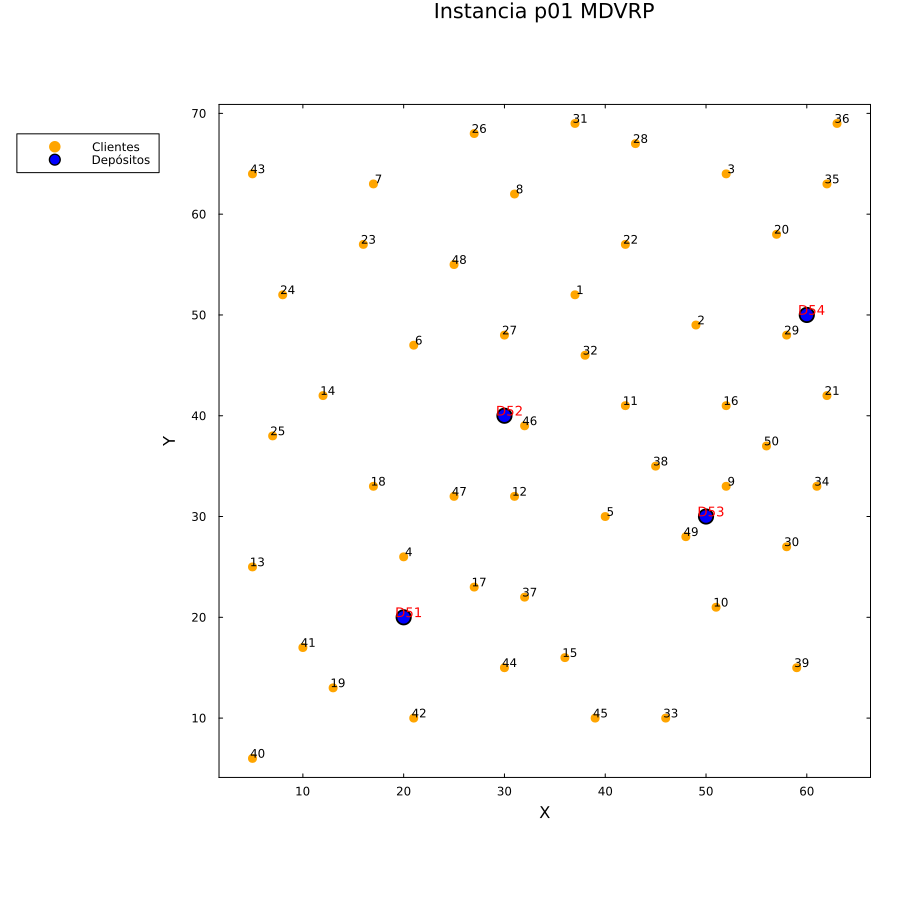

"C:\\Users\\HP\\OneDrive - Universidad Autonoma de Coahuila\\Escritorio\\Maestria CIMA\\Semestre2\\Optimizacion 2\\Tareas\\T004-MLP-modeling\\Resultados\\Graficas_Modelo_Metaheuristico\\Intancia p01 MDVRP.png"

In [16]:
ruta = "C:/Users/HP/OneDrive - Universidad Autonoma de Coahuila/Escritorio/Maestria CIMA/Semestre2/Optimizacion 2/Tareas/T004-MLP-modeling/Resultados/Graficas_Modelo_Metaheuristico"
p = graf_int(clientes,depositos,instancia,"MDVRP")

plot!(
     p,
     framestyle = :box,
     legend = :outertopleft,
     left_margin = -10Plots.mm,
     right_margin = 5Plots.mm,
     top_margin = -10Plots.mm,
     bottom_margin = -10Plots.mm
)

display(p)

ng = "Intancia $instancia MDVRP"

savefig(p, "$ruta/$ng.png")

# Paso 1: Clustering de clientes a depositos

En esta etapa se implementa el primer paso del artículo:

     Asignar cada cliente al depósito más cercano usando distancia euclidiana y capacidad total disponible

El procedimiento es:

1. Ordenar los clientes en orden descendente de demanda
2. Para cada cliente:
     - Calcular la distancia a todos los depósitos
     - Ordenar los depósitos por cercanía
     - Asignar el cliente al depósito más cercano que no viole capacidad
3. Actualizar la carga del depósito

Restricción de capacidad:

Dado que cada depósito cuenta con $m$ vehículos con capacidad $Q$, la capacidad total por depósito es:

$$
\sum q_i \leq mQ
$$


In [17]:
tiempo_total = @elapsed begin
     clientes_ordenados = sort(collect(clientes), by = x -> -x[2][:demanda])

     clusters = Dict(id => Int[] for id in keys(depositos))
     carga = Dict(id => 0 for id in keys(depositos))

     for (idc,C) in clientes_ordenados
          #print(idc,C,"\n")
          
          dist_deps = []
          for idd in keys(depositos)
               #println(idd)
               d = distancias[(idc,idd)]
               push!(dist_deps,(idd,d))
          end

          dist_deps = sort(dist_deps, by = x -> x[2])
          #println(dist_deps)

          asignacion = false

          for (idd, _) in dist_deps
               if carga[idd] + C[:demanda] <= m * Q
                    push!(clusters[idd], idc)
                    carga[idd] += C[:demanda]
                    asignacion = true
                    break
               end
          end
          if !asignacion
               println("⚠️ Cliente $idc no pudo ser asignado por capacidad")
          end
     end
end

1.1090101

In [18]:
for (i,n) in clusters
     println("Desito ",i," -> Se le asignan ",length(n))
end

Desito 51 -> Se le asignan 13
Desito 54 -> Se le asignan 10
Desito 52 -> Se le asignan 16
Desito 53 -> Se le asignan 11


## Visualización clustering

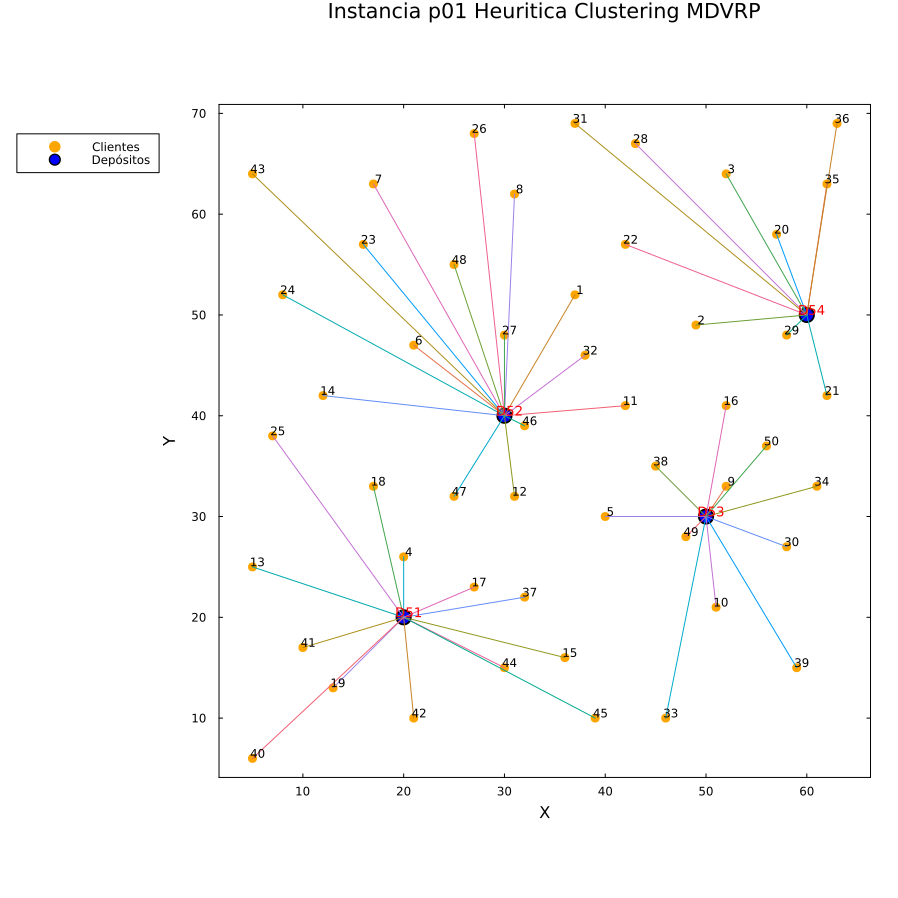

"C:\\Users\\HP\\OneDrive - Universidad Autonoma de Coahuila\\Escritorio\\Maestria CIMA\\Semestre2\\Optimizacion 2\\Tareas\\T004-MLP-modeling\\Resultados\\Graficas_Modelo_Metaheuristico\\Intancia p01 Heuritica Clustering MDVRP.png"

In [19]:
p = graf_int(clientes,depositos,instancia,"Heuritica Clustering MDVRP")

for (idd, lista_clientes) in clusters

     dx = depositos[idd][:x]
     dy = depositos[idd][:y]

     for idc in lista_clientes

          cx = clientes[idc][:x]
          cy = clientes[idc][:y]

          plot!(
               p,
               [cx, dx],
               [cy, dy],
               linewidth = 1,
               label = false
          )
     end
end

plot!(
     p,
     framestyle = :box,
     legend = :outertopleft,
     left_margin = -10Plots.mm,
     right_margin = 5Plots.mm,
     top_margin = -10Plots.mm,
     bottom_margin = -10Plots.mm
)

display(p)

ng = "Intancia $instancia Heuritica Clustering MDVRP"

savefig(p, "$ruta/$ng.png")

# Paso 2: Construcción del modelo matematico exacto por depósito (CVRP)

Después de aplicar la heurística de clustering, el problema original MDVRP se descompone en varios problemas independientes de ruteo de vehículos con capacidad (CVRP), uno por cada depósito.

## Conjuntos

Sea $C_d$ el conjunto de clientes asignados al depósito $d$. Se define el conjunto de nodos como $V = d + C_d$

donde $d$ representa el depósito y $C_d$ los clientes asociados.

## Parametros
- $c_{ij}$: costo o distancia de viajar del nodo $i$ al nodo $j$.
- $q_i$: demanda del cliente $i \in C_d$.
- $Q$: capacidad máxima de cada vehículo.

## Variables de decisión

$$
x_{ij} =
    \begin{cases}
        1 & \text{si se viaja directamente del nodo } i \text{ al nodo } j \\
        0 & \text{en otro caso}
    \end{cases}
$$
    
$$u_i \text{: carga acumulada al llegar al nodo } i$$

## Función objetivo

Minimizar la distancia total recorrida:

$$
\min \sum_{i \in V} \sum_{\substack{j \in V \\ j \neq i}} c_{ij} x_{ij}
$$

## Restricciones

### 1. Eliminación de ciclos triviales
$$
x_{ii} = 0 \quad \forall i \in V
$$

### 2. Entrada única a cada cliente
$$
\sum_{\substack{j \in V \\ j \neq i}} x_{ji} = 1 \quad \forall i \in C_d
$$

### 3. Salida única de cada cliente
$$
\sum_{\substack{j \in V \\ j \neq i}} x_{ij} = 1 \quad \forall i \in C_d
$$

### 4. Número máximo de rutas desde el depósito
$$
\sum_{j \in C_d} x_{dj} \leq m
$$

### 5. Número máximo de rutas hacia el depósito
$$
\sum_{i \in C_d} x_{id} \leq m
$$

### 6. Inicialización de la carga en el depósito
$$
u_d = 0
$$

### 7. Restricciones de capacidad
$$
q_i \leq u_i \leq Q \quad \forall i \in C_d
$$

### 8. Eliminación de subciclos y propagación de carga (MTZ)
$$
u_i - u_j + Q , x_{ij} \leq Q - q_j \quad \forall i,j \in C_d, ; i \neq j
$$

In [20]:
resultados = Dict()

costo_total = 0.0
#tiempo_total = 0.0

for idm in keys(clusters)

     C = clusters[idm]                  # clientes del cluster
     N = vcat([idm], C)                 # depot + clientes
     V = N                              # conjunto de nodos
     D = idm                            # depot

     K = 1:m                            # vehículos disponibles

     # =========================
     # MODELO
     # =========================
     model = Model(HiGHS.Optimizer)

     # =========================
     # VARIABLES
     # =========================
     @variable(model, x[i in V, j in V], Bin)
     @variable(model, u[i in V])  # carga acumulada

     # =========================
     # OBJETIVO
     # =========================
     @objective(model, Min,
          sum(distancias[(i,j)] * x[i,j] for i in V, j in V if i != j)
     )

     # =========================
     # RESTRICCIONES
     # =========================

     # No self-loops
     @constraint(model, [i in V],
          x[i,i] == 0
     )

     # Cada cliente entra exactamente una vez
     @constraint(model, [i in C],
          sum(x[j,i] for j in V if j != i) == 1
     )

     # Cada cliente sale exactamente una vez
     @constraint(model, [i in C],
          sum(x[i,j] for j in V if j != i) == 1
     )

     # Depot: salida y entrada (hasta m rutas)
     @constraint(model,
          sum(x[D,j] for j in C) <= m
     )

     @constraint(model,
          sum(x[i,D] for i in C) <= m
     )

     # =========================
     # MTZ (subtour + capacidad)
     # =========================

     @constraint(model, u[D] == 0)

     @constraint(model, [i in C],
          clientes[i][:demanda] <= u[i] <= Q
     )

     @constraint(model, [i in C, j in C; i != j],
          u[i] - u[j] + Q * x[i,j] <= Q - clientes[j][:demanda]
     )

     # =========================
     # SOLVER
     # =========================
     time_limit = 30.0
     set_silent(model)
     set_optimizer_attribute(model, "time_limit", time_limit)
     set_optimizer_attribute(model, "mip_rel_gap", 0.1)
     tiempo = @elapsed optimize!(model)

     resultados[idm] = (model = model, x = x)

     println("\n====================")
     println("Status: ", termination_status(model))
     println("Costo óptimo: ", objective_value(model))
     println("====================\n")
     if termination_status(model) == MOI.OPTIMAL
          println("Valor óptimo: ", objective_value(model))
     else
          println("No se encontró solución óptima.")
     end

     costo = objective_value(model)

     costo_total += costo
     tiempo_total += tiempo
end


Status: OPTIMAL
Costo óptimo: 162.87631968161554

Valor óptimo: 162.87631968161554

Status: OPTIMAL
Costo óptimo: 125.20682835399371

Valor óptimo: 125.20682835399371

Status: TIME_LIMIT
Costo óptimo: 209.74102651633504

No se encontró solución óptima.

Status: OPTIMAL
Costo óptimo: 115.93647572611894

Valor óptimo: 115.93647572611894


# Resultados

In [24]:
ruta_s = "C:/Users/HP/OneDrive - Universidad Autonoma de Coahuila/Escritorio/Maestria CIMA/Semestre2/Optimizacion 2/Tareas/T004-MLP-modeling/Resultados/Datos_Solucion"

open("$ruta_s/Resultados $instancia Solución Metaheuristica MDVRP.txt", "w") do io
     println(io, "====================")
     println(io, "Instancia: ", instancia)
     println(io, "Tiempo total: ", tiempo_total, " s")
     println(io, "Costo total: ", costo_total)
end

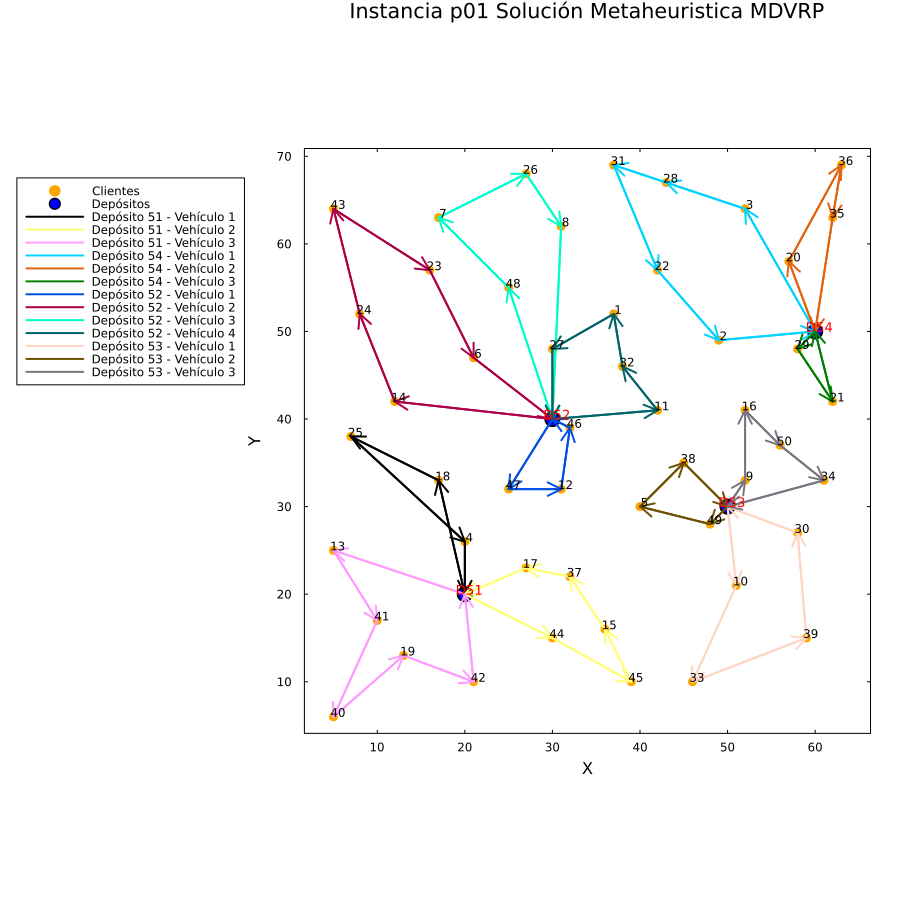

"C:\\Users\\HP\\OneDrive - Universidad Autonoma de Coahuila\\Escritorio\\Maestria CIMA\\Semestre2\\Optimizacion 2\\Tareas\\T004-MLP-modeling\\Resultados\\Graficas_Modelo_Metaheuristico\\Intancia p01 Solución Metaheuristica MDVRP.png"

In [30]:
p = graf_int(clientes, depositos, instancia,"Solución Metaheuristica MDVRP")

colores = distinguishable_colors(length(keys(resultados)) * m)

color_idx = 1

for m_id in keys(resultados)

     model = resultados[m_id][:model]
     x = resultados[m_id][:x]

     C = clusters[m_id]
     D = m_id
     N = vcat([D], C)

     # =========================
     # 1. arcos activos
     # =========================
     arcs = [(i,j) for i in N, j in N if i != j && value(x[i,j]) > 0.5]

     visited_edges = Set(arcs)
     routes = []

     # =========================
     # 2. construir rutas
     # =========================
     while true
          start = nothing
          for (i,j) in visited_edges
               if i == D
                    start = (i,j)
                    break
               end
          end

          if start === nothing
               break
          end

          route = [start[1], start[2]]
          delete!(visited_edges, start)

          current = start[2]

          while current != D
               found = false
               for (i,j) in collect(visited_edges)
                    if i == current
                         push!(route, j)
                         delete!(visited_edges, (i,j))
                         current = j
                         found = true
                         break
                    end
               end
               if !found
                    break
               end
          end

          push!(routes, route)
     end

     # =========================
     # 3. graficar rutas
     # =========================
     vehiculo = 1

     for route in routes

          primer_arco = true  # 🔥 ahora sí correcto

          for k in 1:length(route)-1

               i = route[k]
               j = route[k+1]

               xi, yi = nodos[i]
               xj, yj = nodos[j]

               plot!(
                    p,
                    [xi, xj],
                    [yi, yj],
                    lw = 2,
                    color = colores[color_idx],
                    arrow = :arrow,
                    label = primer_arco ? "Depósito $m_id - Vehículo $vehiculo" : false
               )

               primer_arco = false
          end

          vehiculo += 1
          color_idx += 1
     end
end

plot!(
     p,
     framestyle = :box,
     legend = :outertopleft,
     left_margin = -10Plots.mm,
     right_margin = 5Plots.mm,
     top_margin = -10Plots.mm,
     bottom_margin = -10Plots.mm
)

display(p)

ng = "Intancia $instancia Solución Metaheuristica MDVRP"

savefig(p, "$ruta/$ng.png")

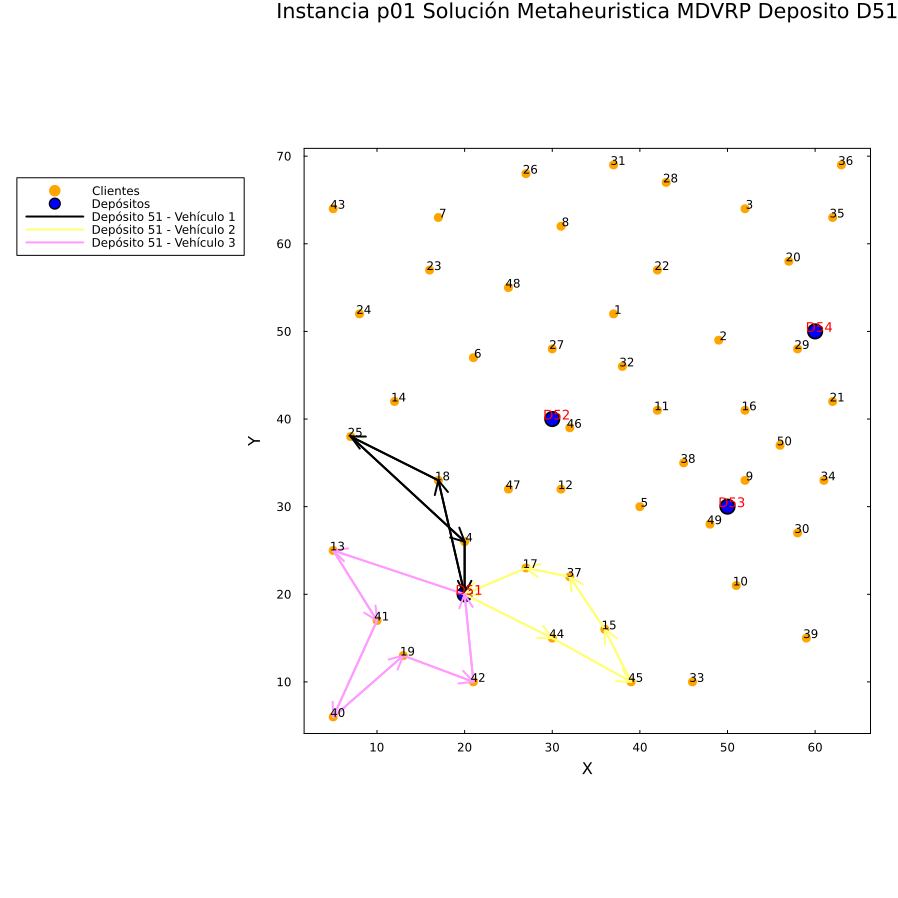

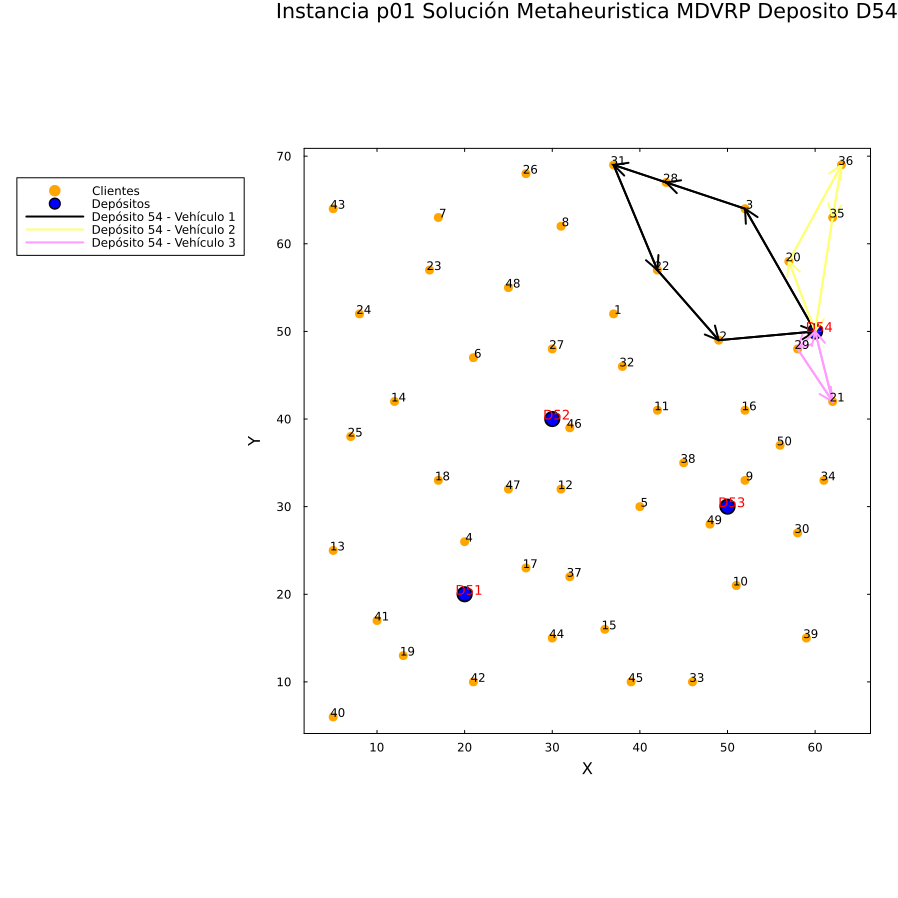

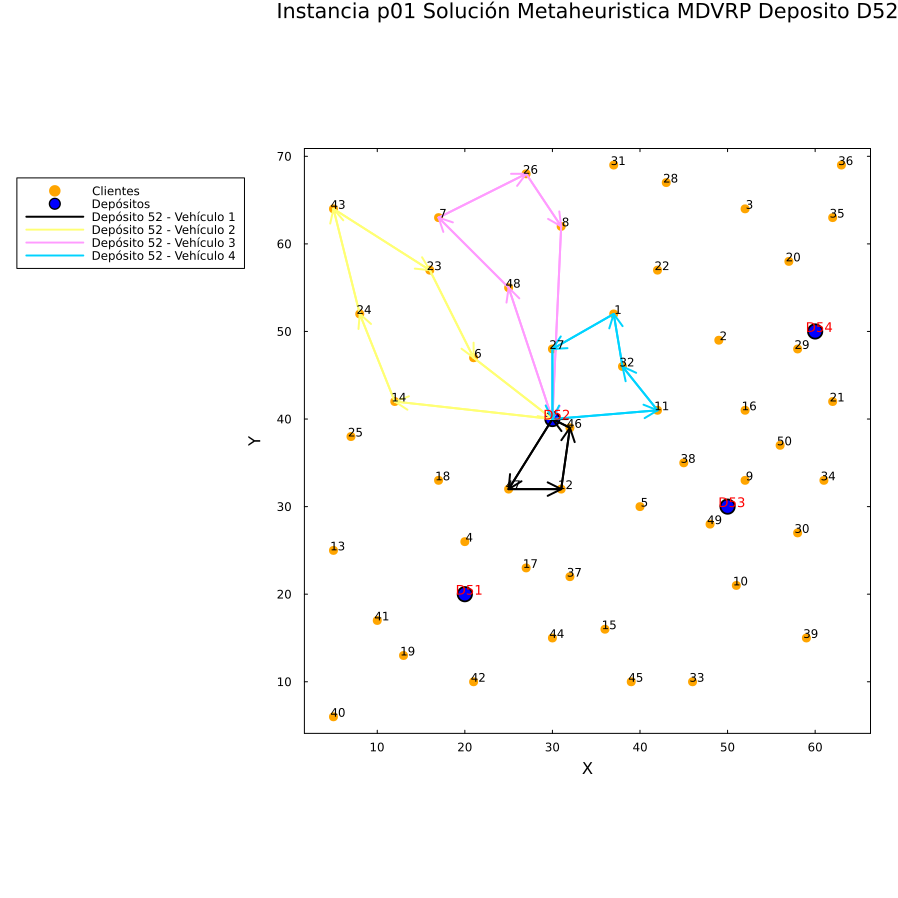

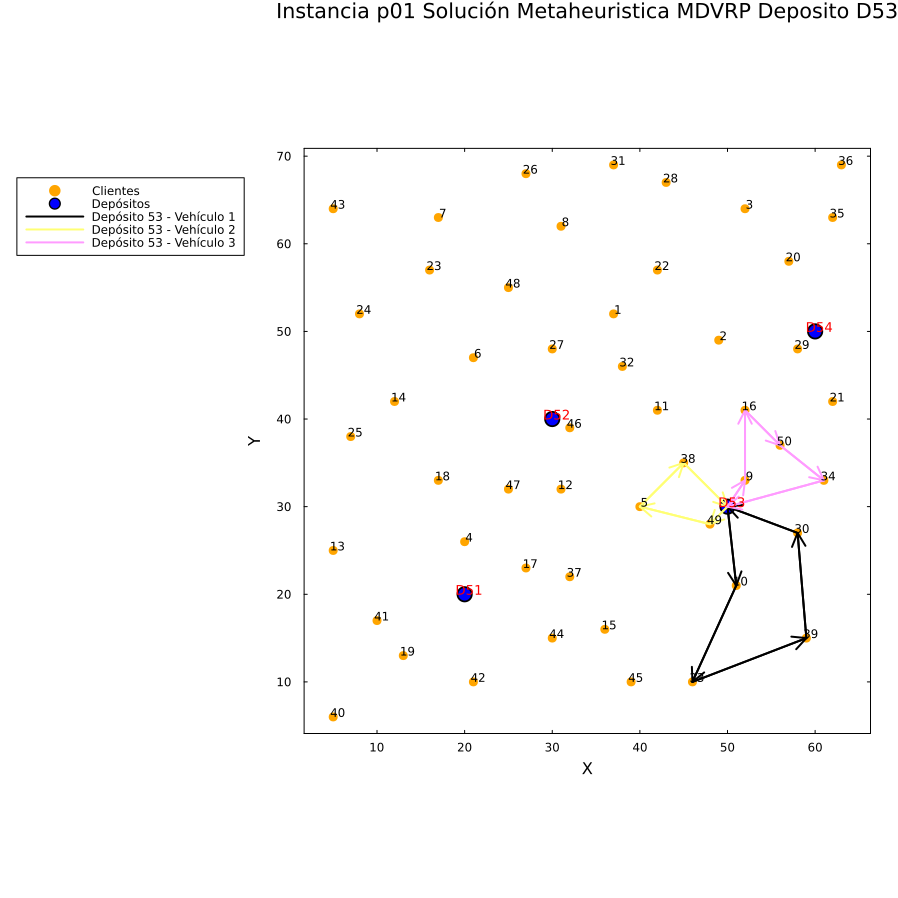

In [33]:
for m_id in keys(resultados)

     # 🔥 nueva gráfica por depósito
     p = graf_int(clientes, depositos, instancia, "Solución Metaheuristica MDVRP Deposito D$m_id")

     model = resultados[m_id][:model]
     x = resultados[m_id][:x]

     C = clusters[m_id]
     D = m_id
     N = vcat([D], C)

     arcs = [(i,j) for i in N, j in N if i != j && value(x[i,j]) > 0.5]

     visited_edges = Set(arcs)
     routes = []

     # construir rutas (igual que ya tienes)
     while true
          start = nothing
          for (i,j) in visited_edges
               if i == D
                    start = (i,j)
                    break
               end
          end

          if start === nothing
               break
          end

          route = [start[1], start[2]]
          delete!(visited_edges, start)

          current = start[2]

          while current != D
               found = false
               for (i,j) in collect(visited_edges)
                    if i == current
                         push!(route, j)
                         delete!(visited_edges, (i,j))
                         current = j
                         found = true
                         break
                    end
               end
               if !found
                    break
               end
          end

          push!(routes, route)
     end

     # colores por vehículo
     colores = distinguishable_colors(length(routes))

     vehiculo = 1

     for route in routes
          primer_arco = true

          for k in 1:length(route)-1
               i = route[k]
               j = route[k+1]

               xi, yi = nodos[i]
               xj, yj = nodos[j]

               plot!(
                    p,
                    [xi, xj],
                    [yi, yj],
                    lw = 2,
                    color = colores[vehiculo],
                    arrow = :arrow,
                    label = primer_arco ? "Depósito $m_id - Vehículo $vehiculo" : false
               )

               primer_arco = false
          end

          vehiculo += 1
     end

     plot!(
          p,
          framestyle = :box,
          legend = :outertopleft,
          left_margin = -10Plots.mm,
          right_margin = 5Plots.mm,
          top_margin = -10Plots.mm,
          bottom_margin = -10Plots.mm
     )
     
     display(p)
     
     ng = "Intancia $instancia Solución Metaheuristica MDVRP Deposito D$m_id"
     
     savefig(p, "$ruta/$ng.png")
end